# Primary example

## Model: 24-bus

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB
import random

# Data initialization

In [2]:
# initialize relevant data
current_filepath = Path('.').resolve().parent
data_path = current_filepath / 'raw-data' / 'larger-model-processed' / '30-bus'

branches_df = pd.read_csv(filepath_or_buffer=data_path / 'branches.csv', skiprows=1)
buses_df = pd.read_csv(filepath_or_buffer=data_path / 'buses.csv', skiprows=1)
ptdf_df = pd.read_csv(filepath_or_buffer=data_path / 'ptdf.csv', skiprows=1)
sf_contingencies_df = pd.read_csv(filepath_or_buffer=data_path / 'sf-contingencies.csv', skiprows=1)


# Bid stack generation

In [3]:
gens = pd.read_csv(filepath_or_buffer=data_path / 'gens.csv', skiprows=1)
gens.head()

,Number of Bus,Name of Bus,ID,Status,Gen MW,Gen Mvar,Min MW,Max MW,AGC,AVR,RegBus Num,Set Volt,Min Mvar,Max Mvar,Enforce MW Limits,Part. Factor,Cost Model
0,1,Glen Lyn,1,Closed,260.95,-16.79,-10000.0,10000.0,YES,YES,1,1.060,0.0,0.0,YES,10000.0,NaN
1,2,Claytor,1,Closed,40.00,50.00,-10000.0,10000.0,YES,YES,2,1.045,-40.0,50.0,YES,10000.0,NaN
2,5,Fieldale,1,Closed,0.00,36.85,-10000.0,10000.0,YES,YES,5,1.010,-40.0,40.0,YES,10000.0,NaN
3,8,Reusens,1,Closed,0.00,37.14,-10000.0,10000.0,YES,YES,8,1.010,-10.0,40.0,YES,10000.0,NaN
4,11,Roanoke,1,Closed,0.00,16.17,-10000.0,10000.0,YES,YES,11,1.082,-6.0,24.0,YES,10000.0,NaN


## Generator Offers

In [4]:
generator_node = gens["Number of Bus"].to_numpy()
generator_min = np.zeros(generator_node.shape[0])
generator_max = np.zeros(generator_node.shape[0])
generator_cost = []
random.seed(370)
np.random.seed(370)

for i in range(generator_node.shape[0]):
    if random.randint(0, 1) == 0:
        generator_min[i] = random.randrange(10, 50, 10)
        generator_max[i] = max(generator_min[i] + 10, int(np.random.normal(125, 25)) * 10)
        
        # Assume non-zero min gen is only for thermal generators
        # Who have agreements to guaruntee production for reliability
        generator_cost.append(random.randrange(10, 15))
    else:
        generator_min[i] = 0
        generator_max[i] = max(generator_min[i] + 10, int(np.random.normal(125, 25)) * 10)
        # Assume renewables dont have min gen since they don't have such agreements
        # However they can effectively "guarantee" production by bidding negative prices
        # since they will always produce, and recieve subsidies for production
        # even if they clear at negative prices, they still make money from the
        # subsidies paying off (and to avoid shutdown costs)
        generator_cost.append(random.randrange(-10, 10))
generator_cost = np.array(generator_cost)

## Load Bids

In [5]:
load_buses = buses_df["Number"].to_numpy()
nominal_demand = buses_df['Load MW'].replace([np.nan], 0).to_numpy()
load_node = buses_df['Number'].to_numpy()
load_node = load_node[nominal_demand != 0]
nominal_demand = nominal_demand[nominal_demand != 0]

In [6]:
load_node = buses_df['Number'].to_numpy()
nodal_bids = []
for bus in load_node:
    num_bids = random.randint(4, 15)
    for i in range(random.randint(4, 15)):
        nodal_bids.append({
            "bus": bus,
            "price": random.randrange(10, 25),
            "amount": random.randrange(10, 50),
        })

bids = pd.DataFrame(nodal_bids).sort_values(by=["bus", "price", "amount"], ignore_index=True, ascending=[True, False, False])
bids.head()

,bus,price,amount
0,1,24,17
1,1,23,24
2,1,22,19
3,1,17,34
4,1,15,45


<Axes: title={'center': 'Bids for power on bus 1'}, xlabel='Price ($/MWh)', ylabel='Amount (MW)'>

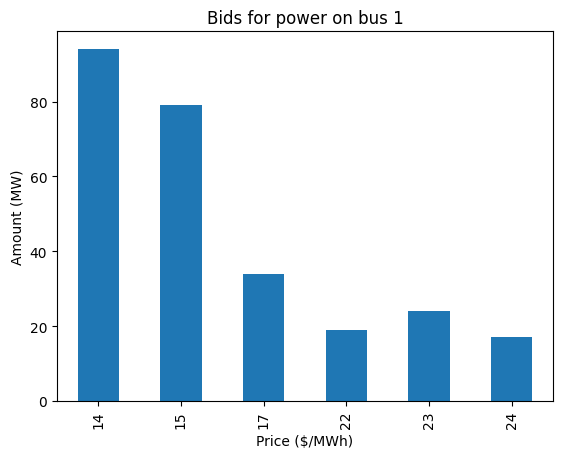

In [7]:
bus_bids = bids[bids["bus"] == 1]
bids[bids["bus"] == 1][
    ["price", "amount"]
    ].groupby("price").sum().reset_index().plot.bar(
        x="price",
        y="amount",
        title="Bids for power on bus 1",
        xlabel="Price ($/MWh)",
        ylabel="Amount (MW)",
        legend=False
        )

# Transmission Constraints

In [8]:
G = generator_cost.shape[0]
D = bids.shape[0]
bid_bus = bids["bus"].to_numpy()
bid_amount = bids["amount"].to_numpy()
bid_price = bids["price"].to_numpy()

thermal_flow_lim = branches_df['Lim MVA A'].to_numpy()

power_balance_cons_vec = np.concatenate((np.ones((G, 1)), -1*np.ones((D, 1)))).T

## Injection Mapping

In [9]:
gen_node_map = np.zeros((buses_df.shape[0], G))
gen_node_map[generator_node - 1, np.arange(G)] = 1
load_node_map = np.zeros((buses_df.shape[0], D))
load_node_map[bid_bus - 1, np.arange(D)] = -1

injection_map = np.hstack((gen_node_map, load_node_map))

## Shift Factor to Thermal Flow Mapping

In [10]:
# Create a mapping from line to thermal flow lim
thermal_flow_mapping = branches_df[['From Number', 'To Number', 'Lim MVA A']]
sf_no_contingency = ptdf_df.iloc[:, 5:]

# match the thermal flow lim to the shift factor values
sf_names = sf_no_contingency.columns.values
thermal_flow_lim = np.zeros((sf_names.shape[0]))
for (ind, line) in enumerate(sf_names):
    line_string = line.split(' ')
    from_no = int(line_string[0])
    to_no = int(line_string[4])
    thermal_flow_lim[ind] = thermal_flow_mapping.query('`From Number` == @from_no and `To Number` == @to_no')['Lim MVA A'].iloc[0]

sf_no_contingency = sf_no_contingency.to_numpy().T

In [11]:
sf_contingency = sf_contingencies_df.iloc[:, 5:]

# match the thermal flow lim to the shift factor contingency values
contingency_names = sf_contingency.columns.values
thermal_flow_lim_contingencies = np.zeros((contingency_names.shape[0]))
for (ind, contingency) in enumerate(contingency_names):
    line_string = contingency.split('_')[2]
    from_no = int(line_string.split('-')[0])
    to_no = int(line_string.split('-')[1])
    thermal_flow_lim_contingencies[ind] = thermal_flow_mapping.query('`From Number` == @from_no and `To Number` == @to_no')['Lim MVA A'].iloc[0]

sf_contingency = sf_contingency.to_numpy().T

In [12]:
base_case_trans_cons_mat = sf_no_contingency @ injection_map
contingency_trans_cons_mat = sf_contingency @ injection_map

## Model Set-up

In [13]:
lp_model = gp.Model()
generators = lp_model.addMVar(G, name='generators')
loads = lp_model.addMVar(D, name='load_served', lb=0.0, ub=bid_amount)


# We maximize served demand - cost of generation
x_dispatch = gp.hstack((generators, loads))
obj_c = np.hstack((-generator_cost, bid_price))
lp_model.setMObjective(Q=None, c=obj_c, xc=x_dispatch, constant=0, sense=GRB.MAXIMIZE)

power_balance_cons = lp_model.addMConstr(power_balance_cons_vec, gp.hstack((generators, loads)), '=', [0], 'power balance')
generator_min_cons = lp_model.addMConstr(np.eye(G), generators, '>=', generator_min, 'min generator capacity')
generator_max_cons = lp_model.addMConstr(np.eye(G), generators, '<=', generator_max, 'max generator capacity')
load_limits_cons = lp_model.addMConstr(np.eye(D), loads, '<=', bid_amount, 'max load bid')
base_case_cons_min = lp_model.addMConstr(base_case_trans_cons_mat, gp.hstack((generators, loads)), '>=', -1*thermal_flow_lim, 'Base Case Transimission Min')
base_case_cons_max = lp_model.addMConstr(base_case_trans_cons_mat, gp.hstack((generators, loads)), '<=', thermal_flow_lim, 'Base Case Transimission Max')
contingency_cons_min = lp_model.addMConstr(contingency_trans_cons_mat, gp.hstack((generators, loads)), '>=', -1*thermal_flow_lim_contingencies, 'Contingency Transimission Min')
contingency_cons_max = lp_model.addMConstr(contingency_trans_cons_mat, gp.hstack((generators, loads)), '<=', thermal_flow_lim_contingencies, 'Contingency Transimission Max')

lp_model.update()
lp_model.write('./DA_Clearance.lp')
lp_model.optimize()

Set parameter Username
Set parameter LicenseID to value 2762801
Academic license - for non-commercial use only - expires 2027-01-10
Set parameter LicenseID to value 2762801
Academic license - for non-commercial use only - expires 2027-01-10
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M1 Max
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 3649 rows, 280 columns and 747772 nonzeros (Max)
Model fingerprint: 0x5fa67081
Model has 280 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-04, 1e+00]
  Objective range  [7e+00, 2e+01]
  Bounds range     [1e+01, 5e+01]
  RHS range        [1e+01, 1e+03]

Presolve removed 2897 rows and 225 columns
Presolve time: 0.06s
Presolved: 752 rows, 263 columns, 35930 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    7.9498666e+04   7.240602e+04   0.000000e+00      0s
      21    2.0276000

## Solutions

In [14]:
load_results = bids.copy().sort_values(by=["bus", "price", "amount"], ignore_index=True, ascending=[True, False, False])
load_results["cleared"] = loads.X
load_results

,bus,price,amount,cleared
0,1,24,17,17.0
1,1,23,24,24.0
2,1,22,19,19.0
3,1,17,34,34.0
4,1,15,45,45.0
...,...,...,...,...
269,30,15,38,0.0
270,30,15,25,0.0
271,30,15,22,0.0
272,30,14,45,0.0


In [15]:
# cleared at each bus
load_results.groupby("bus")["cleared"].sum().reset_index()

,bus,cleared
0,1,173.0
1,2,466.0
2,3,0.0
3,4,0.0
4,5,292.0
5,6,0.0
6,7,0.0
7,8,144.0
8,9,0.0
9,10,0.0


In [16]:
# Shadow prices
power_balance_cons.Pi

array([-14.])

In [17]:
dispatch_vector = np.hstack((generators.X, loads.X))
base_case_flow = base_case_trans_cons_mat @ dispatch_vector

line_loadings_df = pd.DataFrame({
    'Line': sf_names,
    'From Bus': [int(name.split()[0]) for name in sf_names],
    'To Bus': [int(name.split()[2]) for name in sf_names],
    'Flow MW': base_case_flow,
    'Limit MW': thermal_flow_lim
})

line_loadings_df['Abs Flow MW'] = np.abs(line_loadings_df['Flow MW'])
line_loadings_df['% Max Load'] = 100 * line_loadings_df['Abs Flow MW'] / line_loadings_df['Limit MW']
line_loadings_df = line_loadings_df.sort_values('% Max Load', ascending=False).reset_index(drop=True)

line_loadings_df.sort_values("% Max Load", ascending=False).head(20)

,Line,From Bus,To Bus,Flow MW,Limit MW,Abs Flow MW,% Max Load
0,28 TO 27 CKT 1,28,27,-8.881784e-16,0.0,8.881784e-16,inf
8,10 TO 21 CKT 1,10,21,1.776357e-15,0.0,1.776357e-15,inf
13,25 TO 27 CKT 1,25,27,-8.881784e-16,0.0,8.881784e-16,inf
12,24 TO 25 CKT 1,24,25,-8.881784e-16,0.0,8.881784e-16,inf
11,23 TO 24 CKT 1,23,24,-1.776357e-15,0.0,1.776357e-15,inf
10,22 TO 24 CKT 1,22,24,8.881784e-15,0.0,8.881784e-15,inf
1,10 TO 17 CKT 1,10,17,3.552714e-15,0.0,3.552714e-15,inf
9,21 TO 22 CKT 1,21,22,1.776357e-15,0.0,1.776357e-15,inf
7,15 TO 23 CKT 1,15,23,-1.776357e-15,0.0,1.776357e-15,inf
6,12 TO 14 CKT 1,12,14,-2.664535e-15,0.0,2.664535e-15,inf


***